# Chapter 0 — Skill Extraction (Notebook 02 Overview)

This notebook implements the **Skill Extraction Engine (v1)** for the Job Intelligence Engine.  
Its purpose is to transform raw job titles and descriptions into structured, interpretable skill
features that will be used throughout later chapters (salary modelling, job family clustering,
skill demand models, recommendations, etc.).

---

## 1. What This Notebook Achieves

By the end of this notebook, we produce a clean dataset containing:

- The curated **skill taxonomy** (domains × levels)
- The **dictionary-based skill extractor**
- A **set of 27 binary skill features** for every job posting
- A combined text field (`title_plus_description`)
- A deterministic and reproducible skill extraction pipeline

The output file (`jobs_with_skills.csv`) becomes the modelling-ready input for **Chapter 1**.

---

## 2. Why a Dictionary‑Based Approach for v1

Job postings contain:

- extremely noisy and inconsistent language  
- short skill tokens (“R”, “Go”, “C#”) that ML extraction struggles with  
- many industry-specific variants and punctuation forms (“python.”, “c++.”)  

To guarantee **precision, transparency, and reproducibility**, v1 uses a curated taxonomy.

Later project stages may add:

- SBERT fuzzy matching  
- context-aware extraction  
- graph-based skill expansion  

But v1 is intentionally deterministic.

---

## 3. Skill Taxonomy (Summary)

We organise skills into **10 major domains**, each with **3 levels** (basic/intermediate/advanced):

- Core Programming  
- Data Engineering & Pipelines  
- Machine Learning & AI  
- Analytics / Statistics  
- BI & Visualisation  
- Cloud / DevOps / MLOps  
- Databases & Storage  
- Productivity & Workflow  
- Soft Skills (core / leadership)  
- Domain-Specific Skills  

This produces **27 total buckets**.

Each bucket contains a curated list of **explicit tokens**:

- exact strings (including punctuation)
- typos, variants, and alternate spellings

This ensures maximum coverage of noisy real‑world job text.

---

## 4. Token Matching Logic (Summary)

The extractor uses rule-based matching:

- **Whole‑word boundaries** to avoid false positives  
- **Phrase matching** for multi‑word skills  
- **Short token whitelist** (e.g., “r” allowed)  
- Fully **case‑insensitive**  
- No normalisation — tokens match exactly as they appear  

This ensures robustness and avoids the pathological behaviours common in naive regex approaches.

---

## 5. Skill Extraction Output

For each job posting, we generate:

```
core_programming__basic
core_programming__intermediate
core_programming__advanced
data_engineering_pipelines__basic
...
soft_skills__core
soft_skills__leadership
domain_specific__none
```

Each column contains:

- **1** → at least one skill from that bucket was detected  
- **0** → no skills from that bucket were found  

The 27 binary indicators form the skill feature layer for all downstream models.

---

## 6. Final Deliverable of Notebook 02

This notebook produces a fully enriched dataset with:

- cleaned job titles  
- combined description text  
- extracted skill features  
- 27 domain‑level skill indicators  

This dataset is saved and used as the **starting point for Chapter 1**.

The skill taxonomy and extractor are **locked for v1** and form a stable foundation for the rest of the Job Intelligence Engine.


#### Skill taxonomy
1. Core Programming 
2. Data Engineering & Pipelines 
3. Machine Learning & AI 
4. Analytics, Statistics & Experimentation 
5. BI & Visualisation 
6. Cloud, DevOps & MLOps 
7. Databases & Storage 
8. Productivity & Workflow 
9. Soft Skills 
10. Domain-specific skills#

#

#

## Set Up

In [1]:
import sys
from pathlib import Path

project_root = Path().resolve().parent.parent
sys.path.append(str(project_root))
project_root

PosixPath('/Users/alejandrofp/Desktop/Projects/03_Flagship_Portfolio/job-intelligence-engine')

In [2]:
from src.job_intel.config import INTERIM_NORM_TITLE

## Libraries

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import re
from collections import Counter

## Data

In [4]:
df = pd.read_csv(INTERIM_NORM_TITLE)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6162 entries, 0 to 6161
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Job Title              6162 non-null   object 
 1   Job Description        6162 non-null   object 
 2   Rating                 5481 non-null   float64
 3   Size                   5770 non-null   object 
 4   Founded                4525 non-null   float64
 5   Industry               5263 non-null   object 
 6   Sector                 5263 non-null   object 
 7   state                  6162 non-null   object 
 8   state_hq               5750 non-null   object 
 9   sal_min                6161 non-null   float64
 10  sal_max                6161 non-null   float64
 11  sal_mean               6161 non-null   float64
 12  ownership_clean        6162 non-null   object 
 13  job_title_raw          6162 non-null   object 
 14  clean_title_and_roman  6162 non-null   object 
 15  job_

# Skill extraction

## Surface clean

In [5]:
from nltk.corpus import stopwords
stop_words = set(stopwords.words("english"))

whitelist_short = {"c", "r", "js", "go", "c++", "c#", "s3", "ab"}

def surface_cleaning(text):
    if not isinstance(text, str):
        return ""

    text = text.lower()

    # Split everything on punctuation except + and #
    text = re.sub(r"[^a-z0-9+#]+", " ", text)

    tokens = text.split()
    cleaned = []
    seen = set()

    for tok in tokens:

        tok = tok.strip(".,:;!?")

        # Skip slash-combined tokens e.g. analyst/sql, developer/analyst
        if "/" in tok:
            for part in tok.split("/"):
                if len(part) >= 2:
                    cleaned.append(part)
            continue

        # stopwords
        if tok in stop_words:
            continue

        # length filter except whitelist
        if len(tok) < 3 and tok not in whitelist_short:
            continue

        # digits
        if tok.isdigit() or len(re.findall(r"\d", tok)) >= 3:
            continue

        # alphanumeric garbage
        if re.match(r"^[a-z]+[0-9]+[a-z]+$", tok):
            continue

        # too many punctuation markers
        if sum(c in "+.#" for c in tok) > 2:
            continue

        if tok not in seen:
            cleaned.append(tok)
            seen.add(tok)

    return " ".join(cleaned)



In [6]:
df['job_description_clean'] = df['Job Description'].apply(surface_cleaning)

In [7]:
df[['Job Description', 'job_description_clean']]

,Job Description,job_description_clean
0,"ABOUT HOPPER\n\nAt Hopper, we’re on a mission ...",hopper mission make booking travel faster easi...
1,"At Noom, we use scientifically proven methods ...",noom use scientifically proven methods help us...
2,Decode_M\n\nhttps://www.decode-m.com/\n\nData ...,decode https www com data science manager job ...
3,Sapphire Digital seeks a dynamic and driven mi...,sapphire digital seeks dynamic driven mid leve...
4,"Director, Data Science - (200537)\nDescription...",director data science description edelman inte...
...,...,...
6157,Maintains systems to protect data from unautho...,maintains systems protect data unauthorized us...
6158,Position:\nSenior Data Analyst (Corporate Audi...,position senior data analyst corporate audit j...
6159,"Title: Technical Business Analyst (SQL, Data a...",title technical business analyst sql data anal...
6160,Summary\n\nResponsible for working cross-funct...,summary responsible working cross functionally...


### Extract seniority from job description and unified title and description seniority

In [8]:
principal = [r"\bprincipal\b"]

executive = [
    r"\bchief\b",
    r"\bchief [a-z]+ officer\b",
    r"\bvice president\b",
    r"\bsvp\b",
    r"\bvp\b",
    r"\bexecutive\b",
]

assistant = [
    r"\bassistant\b",
]

supervisor = [
    r"\bsupervisor\b",
    r"\bsupervisory\b",
]

lead = [
    r"\bteam lead\b",
    r"\btech lead\b",
]

senior = [
    r"\bsenior\b",
    r"\bsr\b",
    r"\bsr\.\b",
]

manager = [
    r"\bmanager\b",
    r"\bdirector\b",
    r"\bhead of\b",
    r"\bhead[- ]?[\w ]*department\b",
    r"\bofficer\b",
    r"\bavp\b",
]

mid = [
    r"\bmid[- ]?level\b",
    r"\bassociate\b",
    r"\bintermediate\b",
]

junior = [
    r"\bjunior\b",
    r"\bjr\b",
    r"\bjr\.\b",
    r"\bentry level\b",
    r"\binternship\b",
    r"\bintern\b",
    r"\btrainee\b",
    r"\bunpaid\b",
]

# priority order: higher first
seniority_patterns = [
    ("principal",  principal),
    ("executive",  executive),
    ("manager",    manager),
    ("lead",       lead),
    ("senior",     senior),
    ("mid",        mid),
    ("junior",     junior),
    ("assistant",  assistant),
    ("supervisor", supervisor),
]




In [9]:
def detect_seniority(text):
    if not isinstance(text, str):
        return "unknown"

    x = text.lower()
    # optional: restrict to first N chars to avoid noisy paragraphs
    snippet = x[:300]

    for label, patterns in seniority_patterns:
        for pat in patterns:
            if re.search(pat, snippet):
                return label

    return "unknown"

In [10]:
df["seniority_description"] = (
    df["job_description_clean"].fillna("").apply(detect_seniority)
)

In [11]:
def combine_seniority(desc_val, title_val):
    if desc_val != 'unknown':
        return desc_val
    elif title_val != 'unknown':
        return title_val
    else:
        return 'unknown'

df["seniority_combined"] = df.apply(
    lambda row: combine_seniority(row["seniority_description"], row["seniority"]),
    axis=1
)

In [12]:
df[['seniority', 'seniority_description', 'seniority_combined']]

,seniority,seniority_description,seniority_combined
0,senior,unknown,senior
1,unknown,unknown,unknown
2,manager,manager,manager
3,unknown,mid,mid
4,manager,manager,manager
...,...,...,...
6157,unknown,unknown,unknown
6158,senior,senior,senior
6159,unknown,unknown,unknown
6160,unknown,unknown,unknown


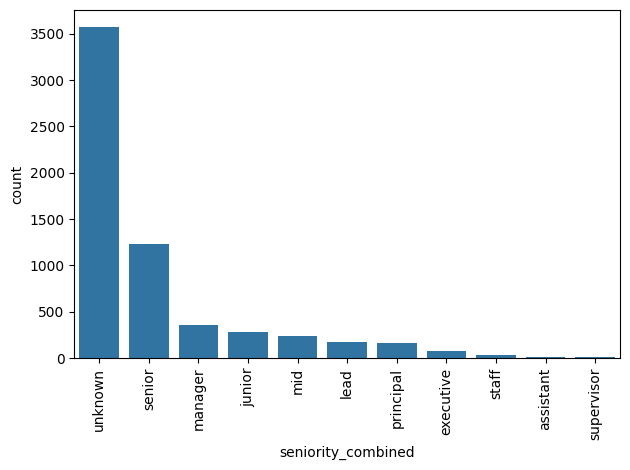

In [13]:
order = df['seniority_combined'].value_counts().index

sns.countplot(
    data = df,
    x = 'seniority_combined',
    order = order
)
plt.xticks(rotation = 90)
plt.tight_layout()

In [14]:
df.head()

,Job Title,Job Description,Rating,Size,Founded,Industry,Sector,state,state_hq,sal_min,...,seniority_roman,seniority,cluster,domain,job_title_norm,job_title_family,job_title_clean,job_description_clean,seniority_description,seniority_combined
0,Senior Data Scientist,"ABOUT HOPPER\n\nAt Hopper, we’re on a mission ...",3.5,501 to 1000 employees,2007.0,Travel Agencies,Travel & Tourism,NY,international,111000.0,...,NaN,senior,14,general_data,data scientist,data_scientist,general_data data_scientist,hopper mission make booking travel faster easi...,unknown,senior
1,"Data Scientist, Product Analytics","At Noom, we use scientifically proven methods ...",4.5,1001 to 5000 employees,2008.0,"Health, Beauty, & Fitness",Consumer Services,NY,NY,111000.0,...,NaN,unknown,1,business,data scientist analyst,data_scientist,business data_scientist,noom use scientifically proven methods help us...,unknown,unknown
2,Data Science Manager,Decode_M\n\nhttps://www.decode-m.com/\n\nData ...,NaN,1 to 50 employees,NaN,NaN,NaN,NY,NY,111000.0,...,NaN,manager,14,general_data,data scientist,data_scientist,general_data data_scientist,decode https www com data science manager job ...,manager,manager
3,Data Analyst,Sapphire Digital seeks a dynamic and driven mi...,3.4,201 to 500 employees,2019.0,Internet,Information Technology,NJ,NJ,111000.0,...,NaN,unknown,25,general_data,data analyst,data_analyst,general_data data_analyst,sapphire digital seeks dynamic driven mid leve...,mid,mid
4,"Director, Data Science","Director, Data Science - (200537)\nDescription...",3.4,51 to 200 employees,2007.0,Advertising & Marketing,Business Services,NY,NY,111000.0,...,NaN,manager,14,general_data,data scientist,data_scientist,general_data data_scientist,director data science description edelman inte...,manager,manager


In [15]:
df["job_title_for_skills"] = (
        df["job_title_raw"]
        .fillna("")
        .str.lower()
        # basic separators → space
        .str.replace(r"[-/|\\,]", " ", regex=True)
        .str.replace(r"[()\[\]{}]", " ", regex=True)
        # other punctuation → space (keep word chars, whitespace, + . # for things like c++ / .net)
        .str.replace(r"[^\w\s+.#]", " ", regex=True)
    )

    # 2) Combine this with the cleaned description
df["title_plus_description"] = (
        df["job_title_for_skills"].astype(str)
        + " "
        + df["job_description_clean"].astype(str)
    )

In [16]:
df[['Job Description', 'title_plus_description']]

,Job Description,title_plus_description
0,"ABOUT HOPPER\n\nAt Hopper, we’re on a mission ...",senior data scientist hopper mission make book...
1,"At Noom, we use scientifically proven methods ...",data scientist product analytics noom use sci...
2,Decode_M\n\nhttps://www.decode-m.com/\n\nData ...,data science manager decode https www com data...
3,Sapphire Digital seeks a dynamic and driven mi...,data analyst sapphire digital seeks dynamic dr...
4,"Director, Data Science - (200537)\nDescription...",director data science director data science d...
...,...,...
6157,Maintains systems to protect data from unautho...,rqs ihha 201900004460 1q data security an...
6158,Position:\nSenior Data Analyst (Corporate Audi...,senior data analyst corporate audit position...
6159,"Title: Technical Business Analyst (SQL, Data a...",technical business analyst sql data analytic...
6160,Summary\n\nResponsible for working cross-funct...,data analyst 3 customer experience summary re...


# Stress-Test the extractor and taxonomy

## Taxonomy test - check the dictionary

In [17]:
from src.job_intel.features.skills_taxonomy import build_skill_index

In [18]:
dictionary_skills = build_skill_index()

In [19]:
dictionary_skills['python']

{'domain': 'core_programming', 'level': 'basic'}

In [20]:
dictionary_skills['aws']

{'domain': 'cloud', 'level': 'basic'}

In [21]:
dictionary_skills['sql']

{'domain': 'db_storage', 'level': 'basic'}

## Extraction test - 1. Check on controlled, clean examples

In [22]:
from src.job_intel.features.skill_extractor import extract_domain_level_flags

text = "We need someone with strong Python and SQL experience."

extract_domain_level_flags(text)



{'core_programming__basic': 1,
 'core_programming__intermediate': 0,
 'core_programming__advanced': 0,
 'data_engineering_pipelines__basic': 0,
 'data_engineering_pipelines__intermediate': 0,
 'data_engineering_pipelines__advanced': 0,
 'ml_ai__basic': 0,
 'ml_ai__intermediate': 0,
 'ml_ai__advanced': 0,
 'analytics_stats__basic': 0,
 'analytics_stats__intermediate': 0,
 'analytics_stats__advanced': 0,
 'bi_viz__basic': 0,
 'bi_viz__intermediate': 0,
 'bi_viz__advanced': 0,
 'cloud__basic': 0,
 'cloud__intermediate': 0,
 'cloud__advanced': 0,
 'db_storage__basic': 1,
 'db_storage__intermediate': 0,
 'db_storage__advanced': 0,
 'productivity_workflow__basic': 0,
 'productivity_workflow__intermediate': 0,
 'productivity_workflow__advanced': 0,
 'soft_skills__core': 0,
 'soft_skills__leadership': 0,
 'domain_specific__none': 0}

In [23]:
from src.job_intel.features.skill_extractor import explain_matches

explain_matches("We need someone with strong Python and SQL experience.")


{'core_programming__basic': ['python'],
 'core_programming__intermediate': [],
 'core_programming__advanced': [],
 'data_engineering_pipelines__basic': [],
 'data_engineering_pipelines__intermediate': [],
 'data_engineering_pipelines__advanced': [],
 'ml_ai__basic': [],
 'ml_ai__intermediate': [],
 'ml_ai__advanced': [],
 'analytics_stats__basic': [],
 'analytics_stats__intermediate': [],
 'analytics_stats__advanced': [],
 'bi_viz__basic': [],
 'bi_viz__intermediate': [],
 'bi_viz__advanced': [],
 'cloud__basic': [],
 'cloud__intermediate': [],
 'cloud__advanced': [],
 'db_storage__basic': ['sql'],
 'db_storage__intermediate': [],
 'db_storage__advanced': [],
 'productivity_workflow__basic': [],
 'productivity_workflow__intermediate': [],
 'productivity_workflow__advanced': [],
 'soft_skills__core': [],
 'soft_skills__leadership': [],
 'domain_specific__none': []}

### It seems to work work as intended in the controlled version

## Apply the extraction to the actual descriptions + titles

In [24]:
df[['job_title_for_skills', 'job_description_clean', 'title_plus_description']]

,job_title_for_skills,job_description_clean,title_plus_description
0,senior data scientist,hopper mission make booking travel faster easi...,senior data scientist hopper mission make book...
1,data scientist product analytics,noom use scientifically proven methods help us...,data scientist product analytics noom use sci...
2,data science manager,decode https www com data science manager job ...,data science manager decode https www com data...
3,data analyst,sapphire digital seeks dynamic driven mid leve...,data analyst sapphire digital seeks dynamic dr...
4,director data science,director data science description edelman inte...,director data science director data science d...
...,...,...,...
6157,rqs ihha 201900004460 1q data security an...,maintains systems protect data unauthorized us...,rqs ihha 201900004460 1q data security an...
6158,senior data analyst corporate audit,position senior data analyst corporate audit j...,senior data analyst corporate audit position...
6159,technical business analyst sql data analytic...,title technical business analyst sql data anal...,technical business analyst sql data analytic...
6160,data analyst 3 customer experience,summary responsible working cross functionally...,data analyst 3 customer experience summary re...


In [25]:
from src.job_intel.features.skill_extractor import extract_domain_level_flags

df["skill_flags"] = df["title_plus_description"].apply(extract_domain_level_flags)


In [26]:
df["skill_flags"].head(3)

0    {'core_programming__basic': 1, 'core_programmi...
1    {'core_programming__basic': 1, 'core_programmi...
2    {'core_programming__basic': 1, 'core_programmi...
Name: skill_flags, dtype: object

In [27]:
features_df = pd.DataFrame(df["skill_flags"].tolist())

In [28]:
df = pd.concat([df, features_df], axis=1)

In [29]:
df.iloc[0][df.columns[-30:]]     # last 30 columns so we can inspect the new one-hot features


job_title_for_skills                                                    senior data scientist
title_plus_description                      senior data scientist hopper mission make book...
skill_flags                                 {'core_programming__basic': 1, 'core_programmi...
core_programming__basic                                                                     1
core_programming__intermediate                                                              0
core_programming__advanced                                                                  0
data_engineering_pipelines__basic                                                           0
data_engineering_pipelines__intermediate                                                    1
data_engineering_pipelines__advanced                                                        0
ml_ai__basic                                                                                0
ml_ai__intermediate                                         

In [30]:
df.head(10)

,Job Title,Job Description,Rating,Size,Founded,Industry,Sector,state,state_hq,sal_min,...,cloud__advanced,db_storage__basic,db_storage__intermediate,db_storage__advanced,productivity_workflow__basic,productivity_workflow__intermediate,productivity_workflow__advanced,soft_skills__core,soft_skills__leadership,domain_specific__none
0,Senior Data Scientist,"ABOUT HOPPER\n\nAt Hopper, we’re on a mission ...",3.5,501 to 1000 employees,2007.0,Travel Agencies,Travel & Tourism,NY,international,111000.0,...,0,1,0,0,0,0,0,1,0,0
1,"Data Scientist, Product Analytics","At Noom, we use scientifically proven methods ...",4.5,1001 to 5000 employees,2008.0,"Health, Beauty, & Fitness",Consumer Services,NY,NY,111000.0,...,0,1,0,0,0,0,0,1,0,0
2,Data Science Manager,Decode_M\n\nhttps://www.decode-m.com/\n\nData ...,NaN,1 to 50 employees,NaN,NaN,NaN,NY,NY,111000.0,...,0,0,0,0,0,0,0,1,1,1
3,Data Analyst,Sapphire Digital seeks a dynamic and driven mi...,3.4,201 to 500 employees,2019.0,Internet,Information Technology,NJ,NJ,111000.0,...,0,1,0,0,0,0,0,1,1,0
4,"Director, Data Science","Director, Data Science - (200537)\nDescription...",3.4,51 to 200 employees,2007.0,Advertising & Marketing,Business Services,NY,NY,111000.0,...,0,0,0,0,0,0,0,1,1,0
5,Data Scientist,Job Brief\n\nThe ideal candidate will have pre...,2.9,201 to 500 employees,1985.0,Insurance Carriers,Insurance,NY,CT,111000.0,...,0,1,0,0,0,0,0,0,0,0
6,Quantitative Researcher,Experience: Entry-level (PhD Program) or Exper...,4.4,51 to 200 employees,1993.0,Investment Banking & Asset Management,Finance,NY,NY,111000.0,...,0,0,0,0,0,0,0,1,0,0
7,Quantitative Research Associate,Seeking a quant to work with senior researcher...,NaN,1 to 50 employees,NaN,NaN,NaN,NY,NY,111000.0,...,0,0,0,0,0,0,0,1,0,0
8,AI Scientist,Paige is a software company helping pathologis...,5.0,1 to 50 employees,2018.0,Enterprise Software & Network Solutions,Information Technology,NY,NY,111000.0,...,0,0,0,0,0,0,0,0,0,0
9,Quantitative Researcher,"About the Position\n\n\nAt Jane Street, we con...",4.8,501 to 1000 employees,2000.0,Investment Banking & Asset Management,Finance,NY,NY,111000.0,...,0,0,0,0,0,0,0,0,0,0


### Check some real case examples

In [31]:
print(df.loc[25, "title_plus_description"])

data scientist  marketplace economics looking data scientist join marketplace economics team within business group mission use science shaping efforts improve spotify strengthening creator sustainability accomplishes combining incentive structure creators intermediate agents labels publishers governmental organizations regulatory bodies internal external test empirical hypotheses build algorithmic measurement performance indicators tools services role using petabytes help products surface insights understand connections artists listeners track impact careers centralized researchers scientists novel research addition possessing strong technical background natural communicator equally comfortable explaining complex economic frameworks engineering teams also preference learning applying causal inference econometric machine statistical techniques accompanying broad set responsibilities exposure many functional areas well senior management across building reporting worldwide music industry 

data scientist  marketplace economics looking data scientist join marketplace economics team within business group mission use science shaping efforts improve spotify strengthening creator sustainability accomplishes combining incentive structure creators intermediate agents labels publishers governmental organizations regulatory bodies internal external test empirical hypotheses build algorithmic measurement performance indicators tools services role using petabytes help products surface insights understand connections artists listeners track impact careers centralized researchers scientists novel research addition possessing strong technical background natural communicator equally comfortable explaining complex economic frameworks engineering teams also preference learning applying causal inference econometric machine statistical techniques accompanying broad set responsibilities exposure many functional areas well senior management across building reporting worldwide music industry trends design maintain iterate suite enable metrics measuring health work closely phd level identify content substitution patterns transition self serve projects balance needs two sided considering goals maintaining listener satisfaction discovery communicate driven recommendations key partners clear visualizations presentations degree mathematics statistics similar quantitative field ability topics plain non language prior proven experience analyzing summarizing via modern sql dialects scripting python preferred stata r visualization dashboards tableau working distributed multiple offices timezones communicative person values relationships colleagues explain simple terms welcome matter come look like playing headphones platform everyone workplace voices represented amplified thrive contribute brilliant bring personal perspectives differences find power keep revolutionizing way world listens transformed listening forever launched unlock potential human creativity giving million creative opportunity live art billions fans enjoy inspired everything love podcasting today popular audio streaming subscription service community users

In [32]:
df.loc[25, "domain"]

'business'

In [33]:
df.loc[25, "seniority_combined"]

'mid'

In [34]:
from src.job_intel.features.skill_extractor import explain_matches

row0_text = df.loc[25, "title_plus_description"]
matches0 = explain_matches(row0_text)
matches0


{'core_programming__basic': ['python', 'r'],
 'core_programming__intermediate': [],
 'core_programming__advanced': [],
 'data_engineering_pipelines__basic': [],
 'data_engineering_pipelines__intermediate': [],
 'data_engineering_pipelines__advanced': ['performance indicators'],
 'ml_ai__basic': ['algorithmic'],
 'ml_ai__intermediate': [],
 'ml_ai__advanced': [],
 'analytics_stats__basic': ['mathematics', 'stata'],
 'analytics_stats__intermediate': [],
 'analytics_stats__advanced': ['causal inference'],
 'bi_viz__basic': [],
 'bi_viz__intermediate': ['dashboards', 'tableau'],
 'bi_viz__advanced': [],
 'cloud__basic': [],
 'cloud__intermediate': [],
 'cloud__advanced': [],
 'db_storage__basic': ['sql'],
 'db_storage__intermediate': [],
 'db_storage__advanced': [],
 'productivity_workflow__basic': [],
 'productivity_workflow__intermediate': [],
 'productivity_workflow__advanced': [],
 'soft_skills__core': [],
 'soft_skills__leadership': ['management'],
 'domain_specific__none': []}

In [ ]:
df

In [53]:
skill_cols = [c for c in df.columns if "__" in c]

summary = df[skill_cols].sum().sort_values(ascending=False)
summary = (
    summary
        .reset_index()
        .rename(columns={"index": "skill_domain", 0: "count"})
)

summary

,skill_domain,count
0,soft_skills__core,4853
1,analytics_stats__basic,4191
2,soft_skills__leadership,4004
3,core_programming__basic,3612
4,db_storage__basic,3413
5,data_engineering_pipelines__intermediate,2365
6,bi_viz__intermediate,2008
7,domain_specific__none,1700
8,db_storage__intermediate,1583
9,cloud__basic,1396


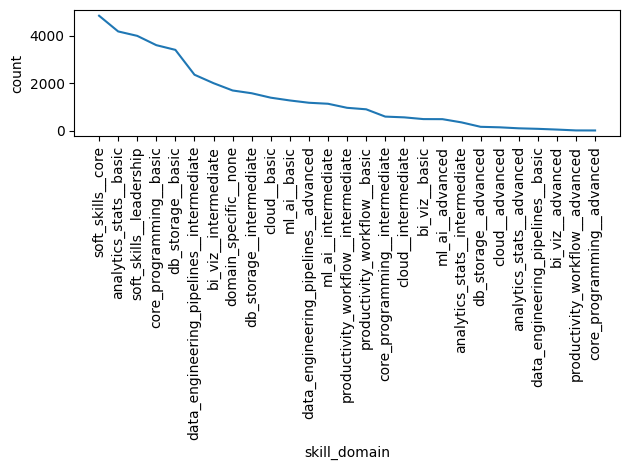

In [58]:
sns.lineplot(
    data = summary,
    x = 'skill_domain',
    y = 'count'
)
plt.xticks(rotation = 90)
plt.tight_layout()

In [36]:
from src.job_intel.config import INTERIM_DATA_DIR
df.to_csv(INTERIM_DATA_DIR / '05_skills_extracted.csv', index=False)

# --- END OF NOTEBOOK ---